/var/folders/3y/ldxff8k17wjcyzkq19xw1srm0000gn/T/ipykernel_16777/1530914022.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2021-01-01', periods=48, freq='M')


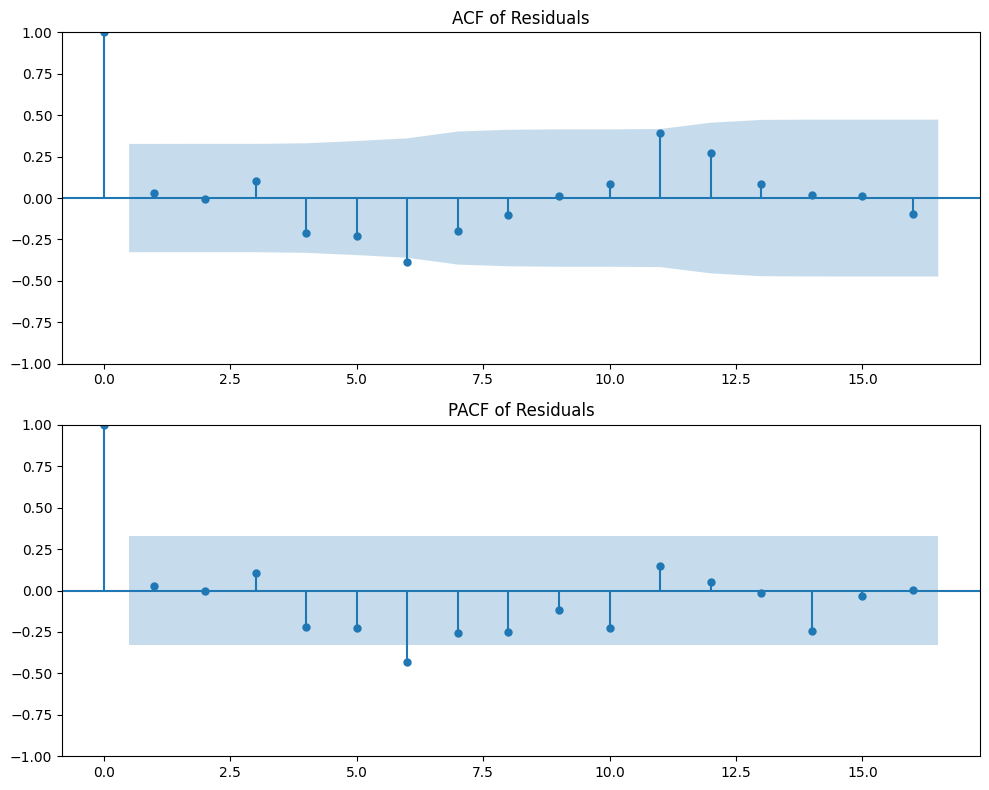

In [1]:
# --- First, we must recreate the model from Reading 20 ---
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

dates = pd.date_range(start='2021-01-01', periods=48, freq='M')
data = np.arange(1, 49) + np.sin(np.arange(1, 49) * (2 * np.pi / 12)) * 10 + np.random.randn(48) * 2
ts = pd.Series(data, index=dates, name='Sales')
train_data = ts.iloc[:-12]
model = ARIMA(train_data, order=(1, 1, 1))
model_fit = model.fit()
# --- End of setup ---


from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Get the model's residuals
residuals = model_fit.resid

# Create a figure for the plots
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Plot the ACF of the residuals
plot_acf(residuals, ax=ax[0])
ax[0].set_title('ACF of Residuals')

# Plot the PACF of the residuals
plot_pacf(residuals, ax=ax[1])
ax[1].set_title('PACF of Residuals')

plt.tight_layout()
plt.show()

In [1]:
import seaborn as sns
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1) load & clean
penguins = sns.load_dataset("penguins")
cols = ["bill_length_mm", "flipper_length_mm", "species"]
df = penguins[cols].dropna()

X = df[["bill_length_mm", "flipper_length_mm"]]
y = df['species']

# 2 ) split(80/20), stratify to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)

# 3) Build pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter = 1000))
])

# 4) fit on TRAIN only
pipe.fit(X_train, y_train)

# 5) evaluate on TEST
y_pred = pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy (TRAIN -TEST): {acc:.3f}")

# 6) Save the TRAIN-fitted model
joblib.dump(pipe, "penguin_model.pkl")

# 7) save slider metadeta from TRAIN ranges, (keeps UI consistent with training dist)

meta = {
    "bill_length_mm": (float(X_train.bill_length_mm.min()), float(X_train.bill_length_mm.max())),
    "flipper_length_mm": (float(X_train.flipper_length_mm.min()), float(X_train.flipper_length_mm.max())),
    "bill_length_default": (float(X_train.bill_length_mm.mean())),
    "flipper_length_default": (float(X_train.flipper_length_mm.mean())),
    "classes": pipe.classes_.tolist(),
    "test_accuracy": float(acc)
}

pd.Series(meta).to_json("penguin_meta.json")

print("Saved penguin_model.pkl and penguin_meta.json")

Test Accuracy (TRAIN -TEST): 0.986
Saved penguin_model.pkl and penguin_meta.json
